# 공시지가 상승률 EDA

목표는 `2차전처리_공시지가데이터.csv`를 사용해서 성남시 법정동별 공시지가 상승률을 확인하는 것이다. 현재 데이터는 2023~2025년 1월 자료가 대부분이고 7월 자료는 극소수라서, 분기별 상승률이 아니라 **연도별 1월 기준 상승률**로 분석한다.

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

price_formatter = FuncFormatter(lambda x, pos: f"{x / 1_000_000:.1f}백만")
rate_formatter = FuncFormatter(lambda x, pos: f"{x:.0%}")
pd.options.display.float_format = "{:,.4f}".format

def format_growth_table(data, money_cols=None, rate_cols=None):
    """jinja2 없이도 노트북에서 보기 좋게 표시하기 위한 간단 포맷터."""
    out = data.copy()
    for col in money_cols or []:
        if col in out.columns:
            out[col] = out[col].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
    for col in rate_cols or []:
        if col in out.columns:
            out[col] = out[col].map(lambda x: f"{x:.2%}" if pd.notna(x) else "")
    return out

## 1. 데이터 불러오기

사용 데이터는 `data/2차전처리_공시지가데이터.csv`이다. 주요 컬럼은 `고유번호`, `법정동명`, `구`, `기준연도`, `기준월`, `공시지가`, `표준지여부`, `건물용도분류명`이다. 여기서 `고유번호`는 같은 필지를 연도별로 추적할 때 사용한다.

In [11]:
DATA_PATH_CANDIDATES = [
    Path("../data/2차전처리_공시지가데이터.csv"),
    Path("data/2차전처리_공시지가데이터.csv"),
]
DATA_PATH = next((path for path in DATA_PATH_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("공시지가 CSV 파일을 찾지 못했습니다. data 폴더 위치를 확인하세요.")

df = pd.read_csv(DATA_PATH, encoding="utf-8")
df["공시지가"] = pd.to_numeric(df["공시지가"], errors="coerce")
df["기준년월"] = pd.to_datetime(df["기준년월"], errors="coerce")
df["법정동"] = df["법정동명"].astype(str).str.split().str[-1]

print(f"사용 데이터: {DATA_PATH}")
print(f"행 수: {len(df):,} / 컬럼 수: {df.shape[1]:,}")
display(df.head())

사용 데이터: ..\data\2차전처리_공시지가데이터.csv
행 수: 15,542 / 컬럼 수: 14


,고유번호,법정동코드,법정동명,특수지구분명,지번,기준연도,기준월,공시지가,표준지여부,기준년월,건물용도분류명,구,공시지가_log,법정동
0,4113511700100760002,4113511700,경기도 성남시 분당구 석운동,일반,76-2,2023,1,1014000,N,2023-01-01,상업용,분당구,13.8294,석운동
1,4113511700100780006,4113511700,경기도 성남시 분당구 석운동,일반,78-6,2023,1,1361000,N,2023-01-01,상업용,분당구,14.1237,석운동
2,4113511700100780007,4113511700,경기도 성남시 분당구 석운동,일반,78-7,2023,1,1361000,N,2023-01-01,상업용,분당구,14.1237,석운동
3,4113511700100780009,4113511700,경기도 성남시 분당구 석운동,일반,78-9,2023,1,1361000,N,2023-01-01,상업용,분당구,14.1237,석운동
4,4113511700100780010,4113511700,경기도 성남시 분당구 석운동,일반,78-10,2023,1,1361000,N,2023-01-01,상업용,분당구,14.1237,석운동


## 2. 기간 커버리지 확인

분기별 상승률을 만들려면 각 분기마다 충분한 필지 자료가 있어야 한다. 하지만 이 데이터는 1월 자료가 대부분이고 7월 자료는 극소수이므로, 7월 자료를 분기 분석에 쓰면 일부 필지만 반영되어 왜곡된다.

In [12]:
month_coverage = (
    df.groupby(["기준연도", "기준월"])
    .size()
    .reset_index(name="필지수")
    .sort_values(["기준연도", "기준월"])
)
display(month_coverage)

basic_summary = pd.DataFrame(
    {
        "항목": ["전체 행 수", "법정동 수", "구 수", "건물용도분류 수", "공시지가 결측", "공시지가 0 이하"],
        "값": [
            len(df),
            df["법정동명"].nunique(),
            df["구"].nunique(),
            df["건물용도분류명"].nunique(),
            df["공시지가"].isna().sum(),
            (df["공시지가"] <= 0).sum(),
        ],
    }
)
display(basic_summary)

,기준연도,기준월,필지수
0,2023,1,5177
1,2023,7,1
2,2024,1,5177
3,2024,7,5
4,2025,1,5177
5,2025,7,5


,항목,값
0,전체 행 수,15542
1,법정동 수,43
2,구 수,3
3,건물용도분류 수,1
4,공시지가 결측,0
5,공시지가 0 이하,0


## 3. 상승률 계산 방식

법정동별 평균 공시지가를 바로 나누면 매년 표본 구성이 달라질 때 왜곡될 수 있다. 그래서 먼저 같은 `고유번호` 필지가 2023년 1월, 2024년 1월, 2025년 1월에 모두 있는지 확인하고, **동일 필지 기준 상승률**을 계산한 뒤 법정동별로 집계한다.

- `상승률_23_24` = 2024년 1월 공시지가 / 2023년 1월 공시지가 - 1
- `상승률_24_25` = 2025년 1월 공시지가 / 2024년 1월 공시지가 - 1
- `상승률_23_25` = 2025년 1월 공시지가 / 2023년 1월 공시지가 - 1
- `연평균상승률_23_25` = 2023~2025년 2년간의 CAGR

In [13]:
ANALYSIS_YEARS = [2023, 2024, 2025]
january_df = df[df["기준월"].eq(1)].copy()

price_wide = january_df.pivot_table(
    index="고유번호",
    columns="기준연도",
    values="공시지가",
    aggfunc="first",
)
complete_wide = price_wide.dropna(subset=ANALYSIS_YEARS).copy()

meta_cols = ["법정동코드", "법정동명", "법정동", "구", "지번", "표준지여부", "건물용도분류명"]
parcel_meta = (
    january_df.sort_values(["고유번호", "기준연도"])
    .drop_duplicates("고유번호")
    .set_index("고유번호")[meta_cols]
)

parcel_growth = (
    complete_wide[ANALYSIS_YEARS]
    .join(parcel_meta, how="left")
    .reset_index()
    .rename(columns={2023: "공시지가_2023", 2024: "공시지가_2024", 2025: "공시지가_2025"})
)

parcel_growth["상승률_23_24"] = parcel_growth["공시지가_2024"] / parcel_growth["공시지가_2023"] - 1
parcel_growth["상승률_24_25"] = parcel_growth["공시지가_2025"] / parcel_growth["공시지가_2024"] - 1
parcel_growth["상승률_23_25"] = parcel_growth["공시지가_2025"] / parcel_growth["공시지가_2023"] - 1
parcel_growth["연평균상승률_23_25"] = (parcel_growth["공시지가_2025"] / parcel_growth["공시지가_2023"]) ** (1 / 2) - 1

coverage_check = pd.DataFrame(
    {
        "구분": ["1월 기준 전체 고유번호", "2023~2025 모두 존재", "상승률 계산 제외"],
        "필지수": [price_wide.shape[0], len(complete_wide), price_wide.shape[0] - len(complete_wide)],
    }
)
display(coverage_check)
display(parcel_growth.head())

,구분,필지수
0,1월 기준 전체 고유번호,5178
1,2023~2025 모두 존재,5176
2,상승률 계산 제외,2


,고유번호,공시지가_2023,공시지가_2024,공시지가_2025,법정동코드,법정동명,법정동,구,지번,표준지여부,건물용도분류명,상승률_23_24,상승률_24_25,상승률_23_25,연평균상승률_23_25
0,4113110100100300002,"6,192,000.0000","6,300,000.0000","6,669,000.0000",4113110100,경기도 성남시 수정구 신흥동,신흥동,수정구,30-2,N,상업용,0.0174,0.0586,0.0770,0.0378
1,4113110100100300005,"6,192,000.0000","6,300,000.0000","6,669,000.0000",4113110100,경기도 성남시 수정구 신흥동,신흥동,수정구,30-5,N,상업용,0.0174,0.0586,0.0770,0.0378
2,4113110100100320000,"5,908,000.0000","6,011,000.0000","6,363,000.0000",4113110100,경기도 성남시 수정구 신흥동,신흥동,수정구,32,N,상업용,0.0174,0.0586,0.0770,0.0378
3,4113110100100340000,"5,845,000.0000","5,947,000.0000","6,296,000.0000",4113110100,경기도 성남시 수정구 신흥동,신흥동,수정구,34,N,상업용,0.0175,0.0587,0.0772,0.0379
4,4113110100100370000,"2,453,000.0000","2,496,000.0000","2,595,000.0000",4113110100,경기도 성남시 수정구 신흥동,신흥동,수정구,37,N,상업용,0.0175,0.0397,0.0579,0.0285


## 4. 상승률 이상값 확인

공시지가 상승률은 일부 필지에서 큰 변동이 생길 수 있다. 법정동 대표값은 평균보다 **중앙값**을 우선 사용한다. 평균은 큰 상승 또는 큰 하락 필지 하나에 의해 쉽게 흔들릴 수 있기 때문이다.

In [14]:
rate_cols = ["상승률_23_24", "상승률_24_25", "상승률_23_25", "연평균상승률_23_25"]
audit = []
for col in rate_cols:
    s = parcel_growth[col]
    audit.append(
        {
            "지표": col,
            "최소": s.min(),
            "1%": s.quantile(0.01),
            "중앙값": s.median(),
            "평균": s.mean(),
            "99%": s.quantile(0.99),
            "최대": s.max(),
            "음수 필지수": (s < 0).sum(),
            "무한대/결측": (~np.isfinite(s)).sum(),
        }
    )
audit_df = pd.DataFrame(audit)
display(format_growth_table(audit_df, rate_cols=["최소", "1%", "중앙값", "평균", "99%", "최대"]))

extreme_cols = ["고유번호", "구", "법정동", "공시지가_2023", "공시지가_2024", "공시지가_2025", "상승률_23_25"]
print("2023~2025 누적 상승률 하위 5개 필지")
display(format_growth_table(parcel_growth.nsmallest(5, "상승률_23_25")[extreme_cols], money_cols=["공시지가_2023", "공시지가_2024", "공시지가_2025"], rate_cols=["상승률_23_25"]))

print("2023~2025 누적 상승률 상위 5개 필지")
display(format_growth_table(parcel_growth.nlargest(5, "상승률_23_25")[extreme_cols], money_cols=["공시지가_2023", "공시지가_2024", "공시지가_2025"], rate_cols=["상승률_23_25"]))

,지표,최소,1%,중앙값,평균,99%,최대,음수 필지수,무한대/결측
0,상승률_23_24,-12.70%,-1.44%,1.51%,1.85%,6.42%,21.08%,166,0
1,상승률_24_25,-20.01%,-4.71%,3.05%,3.49%,9.01%,468.70%,90,0
2,상승률_23_25,-17.85%,-3.17%,5.01%,5.41%,14.11%,504.31%,96,0
3,연평균상승률_23_25,-9.36%,-1.60%,2.48%,2.64%,6.82%,145.83%,96,0


2023~2025 누적 상승률 하위 5개 필지


,고유번호,구,법정동,공시지가_2023,공시지가_2024,공시지가_2025,상승률_23_25
4397,4113510700102030000,분당구,야탑동,"5,719,000","5,719,000","4,698,000",-17.85%
4089,4113510500100990004,분당구,서현동,"5,170,000","5,371,000","4,296,000",-16.91%
4094,4113510500101040001,분당구,서현동,"4,909,000","5,152,000","4,202,000",-14.40%
4088,4113510500100990003,분당구,서현동,"5,014,000","5,209,000","4,296,000",-14.32%
199,4113110100138530000,수정구,신흥동,"6,727,000","6,316,000","5,897,000",-12.34%


2023~2025 누적 상승률 상위 5개 필지


,고유번호,구,법정동,공시지가_2023,공시지가_2024,공시지가_2025,상승률_23_25
2019,4113111600100870005,수정구,금토동,"404,100","429,400","2,442,000",504.31%
2629,4113310300128540000,중원구,금광동,"2,419,000","2,432,000","4,792,000",98.10%
4704,4113511000104070022,분당구,백현동,"2,611,000","2,644,000","3,924,000",50.29%
4943,4113511300103080003,분당구,동원동,"2,183,000","2,587,000","3,051,000",39.76%
4944,4113511300103100002,분당구,동원동,"2,095,000","2,368,000","2,829,000",35.04%


## 5. 법정동별 상승률 집계

법정동별 집계에서는 필지별 상승률의 **중앙값**을 대표 지표로 사용한다.

중앙값은 해당 법정동 안의 필지 상승률을 낮은 값부터 높은 값까지 정렬했을 때 가운데에 있는 값이다. 예를 들어 어떤 동에 필지가 100개 있다면, 중앙값은 50번째 정도 필지의 상승률이라고 보면 된다.

평균 대신 중앙값을 쓰는 이유는 공시지가 상승률이 일부 필지에 의해 크게 흔들릴 수 있기 때문이다. 특정 필지 하나가 재평가, 용도 변화, 지번 특성 등으로 매우 크게 오르면 평균 상승률은 확 올라가지만, 그 동 전체 필지가 일반적으로 많이 올랐다고 보기는 어렵다. 반대로 중앙값은 이런 극단값의 영향을 덜 받아서 **그 동의 일반적인 필지들이 얼마나 올랐는지**를 보기 좋다.

따라서 이번 EDA에서는 법정동 순위와 그래프 해석에 평균보다 중앙값을 우선 사용했다. 평균은 참고용으로 계산해두되, 지역 간 비교는 중앙값 기준이 더 안정적이다. 시각화와 순위표는 표본 수가 너무 작은 법정동을 제외하기 위해 `필지수 >= 20` 조건을 적용했다.

In [15]:
dong_growth = (
    parcel_growth.groupby(["구", "법정동명", "법정동"], as_index=False)
    .agg(
        필지수=("고유번호", "size"),
        공시지가_2023_중앙=("공시지가_2023", "median"),
        공시지가_2024_중앙=("공시지가_2024", "median"),
        공시지가_2025_중앙=("공시지가_2025", "median"),
        상승률_23_24_중앙=("상승률_23_24", "median"),
        상승률_24_25_중앙=("상승률_24_25", "median"),
        상승률_23_25_중앙=("상승률_23_25", "median"),
        연평균상승률_23_25_중앙=("연평균상승률_23_25", "median"),
        상승률_23_25_평균=("상승률_23_25", "mean"),
    )
)

dong_growth_filtered = dong_growth[dong_growth["필지수"] >= 20].copy()
display_cols = [
    "구", "법정동", "필지수",
    "공시지가_2023_중앙", "공시지가_2024_중앙", "공시지가_2025_중앙",
    "상승률_23_24_중앙", "상승률_24_25_중앙", "상승률_23_25_중앙", "연평균상승률_23_25_중앙",
]
formatters = {
    "공시지가_2023_중앙": "{:,.0f}",
    "공시지가_2024_중앙": "{:,.0f}",
    "공시지가_2025_중앙": "{:,.0f}",
    "상승률_23_24_중앙": "{:.2%}",
    "상승률_24_25_중앙": "{:.2%}",
    "상승률_23_25_중앙": "{:.2%}",
    "연평균상승률_23_25_중앙": "{:.2%}",
}

print("법정동별 2023~2025 누적 상승률 상위")
display(format_growth_table(dong_growth_filtered.sort_values("상승률_23_25_중앙", ascending=False).head(15)[display_cols], money_cols=["공시지가_2023_중앙", "공시지가_2024_중앙", "공시지가_2025_중앙"], rate_cols=["상승률_23_24_중앙", "상승률_24_25_중앙", "상승률_23_25_중앙", "연평균상승률_23_25_중앙"]))

print("법정동별 2023~2025 누적 상승률 하위")
display(format_growth_table(dong_growth_filtered.sort_values("상승률_23_25_중앙", ascending=True).head(15)[display_cols], money_cols=["공시지가_2023_중앙", "공시지가_2024_중앙", "공시지가_2025_중앙"], rate_cols=["상승률_23_24_중앙", "상승률_24_25_중앙", "상승률_23_25_중앙", "연평균상승률_23_25_중앙"]))

법정동별 2023~2025 누적 상승률 상위


,구,법정동,필지수,공시지가_2023_중앙,공시지가_2024_중앙,공시지가_2025_중앙,상승률_23_24_중앙,상승률_24_25_중앙,상승률_23_25_중앙,연평균상승률_23_25_중앙
26,수정구,시흥동,99,"2,965,000","3,104,000","3,210,000",6.33%,2.85%,9.37%,4.58%
7,분당구,삼평동,73,"5,416,000","5,572,000","5,967,000",1.94%,7.00%,9.04%,4.42%
5,분당구,백현동,61,"4,279,000","4,499,000","4,806,000",3.62%,4.52%,8.57%,4.20%
19,수정구,금토동,50,"2,913,500","2,945,000","3,122,000",3.51%,3.66%,8.02%,3.93%
8,분당구,서현동,189,"5,287,000","5,379,000","5,540,000",3.89%,4.09%,7.97%,3.91%
2,분당구,금곡동,93,"3,944,000","3,997,000","4,118,000",4.49%,3.02%,7.75%,3.80%
32,수정구,창곡동,35,"6,266,000","6,501,000","6,723,000",3.71%,4.13%,7.69%,3.77%
1,분당구,궁내동,70,"3,036,000","3,061,000","3,206,500",2.14%,4.68%,7.68%,3.77%
31,수정구,오야동,21,"2,718,000","2,777,000","2,920,000",2.17%,5.14%,7.43%,3.65%
16,분당구,판교동,53,"6,360,000","6,635,000","6,960,000",3.92%,3.04%,7.37%,3.62%


법정동별 2023~2025 누적 상승률 하위


,구,법정동,필지수,공시지가_2023_중앙,공시지가_2024_중앙,공시지가_2025_중앙,상승률_23_24_중앙,상승률_24_25_중앙,상승률_23_25_중앙,연평균상승률_23_25_중앙
24,수정구,상적동,85,"2,811,000","2,856,000","2,880,000",1.67%,0.88%,2.59%,1.28%
37,중원구,상대원동,403,"3,556,000","3,591,000","3,647,000",0.94%,2.67%,3.17%,1.57%
35,중원구,금광동,305,"5,013,000","4,991,000","5,124,000",0.55%,2.67%,3.22%,1.60%
39,중원구,여수동,33,"4,730,000","4,778,000","4,982,000",1.00%,2.73%,3.76%,1.86%
36,중원구,도촌동,21,"3,713,000","3,751,000","3,853,000",1.00%,2.70%,3.77%,1.87%
38,중원구,성남동,392,"5,649,000","5,695,000","5,881,500",0.84%,2.97%,3.84%,1.90%
42,중원구,하대원동,167,"3,675,000","3,713,000","3,830,000",0.95%,3.00%,3.96%,1.96%
40,중원구,은행동,120,"4,653,500","4,690,500","4,831,500",1.01%,3.02%,4.05%,2.01%
29,수정구,심곡동,23,"2,263,000","2,293,000","2,376,000",0.84%,3.55%,4.43%,2.19%
33,수정구,태평동,551,"4,052,000","4,113,000","4,238,000",1.64%,3.10%,4.74%,2.34%


In [16]:
gu_growth = (
    parcel_growth.groupby("구", as_index=False)
    .agg(
        필지수=("고유번호", "size"),
        공시지가_2023_중앙=("공시지가_2023", "median"),
        공시지가_2025_중앙=("공시지가_2025", "median"),
        상승률_23_24_중앙=("상승률_23_24", "median"),
        상승률_24_25_중앙=("상승률_24_25", "median"),
        상승률_23_25_중앙=("상승률_23_25", "median"),
        연평균상승률_23_25_중앙=("연평균상승률_23_25", "median"),
    )
    .sort_values("상승률_23_25_중앙", ascending=False)
)
display(format_growth_table(gu_growth, money_cols=["공시지가_2023_중앙", "공시지가_2025_중앙"], rate_cols=["상승률_23_24_중앙", "상승률_24_25_중앙", "상승률_23_25_중앙", "연평균상승률_23_25_중앙"]))

,구,필지수,공시지가_2023_중앙,공시지가_2025_중앙,상승률_23_24_중앙,상승률_24_25_중앙,상승률_23_25_중앙,연평균상승률_23_25_중앙
0,분당구,1416,"4,896,000","5,145,500",3.18%,3.08%,6.86%,3.37%
1,수정구,2141,"4,111,000","4,329,000",1.68%,3.35%,5.29%,2.61%
2,중원구,1619,"4,468,000","4,644,000",0.80%,2.80%,3.67%,1.82%


## 6. 시각화

아래 그래프는 법정동별 2023~2025년 누적 상승률 중앙값을 기준으로 상위/하위 법정동을 비교한다. 상승률은 필지별 상승률을 먼저 계산한 뒤 법정동별 중앙값으로 집계했다.

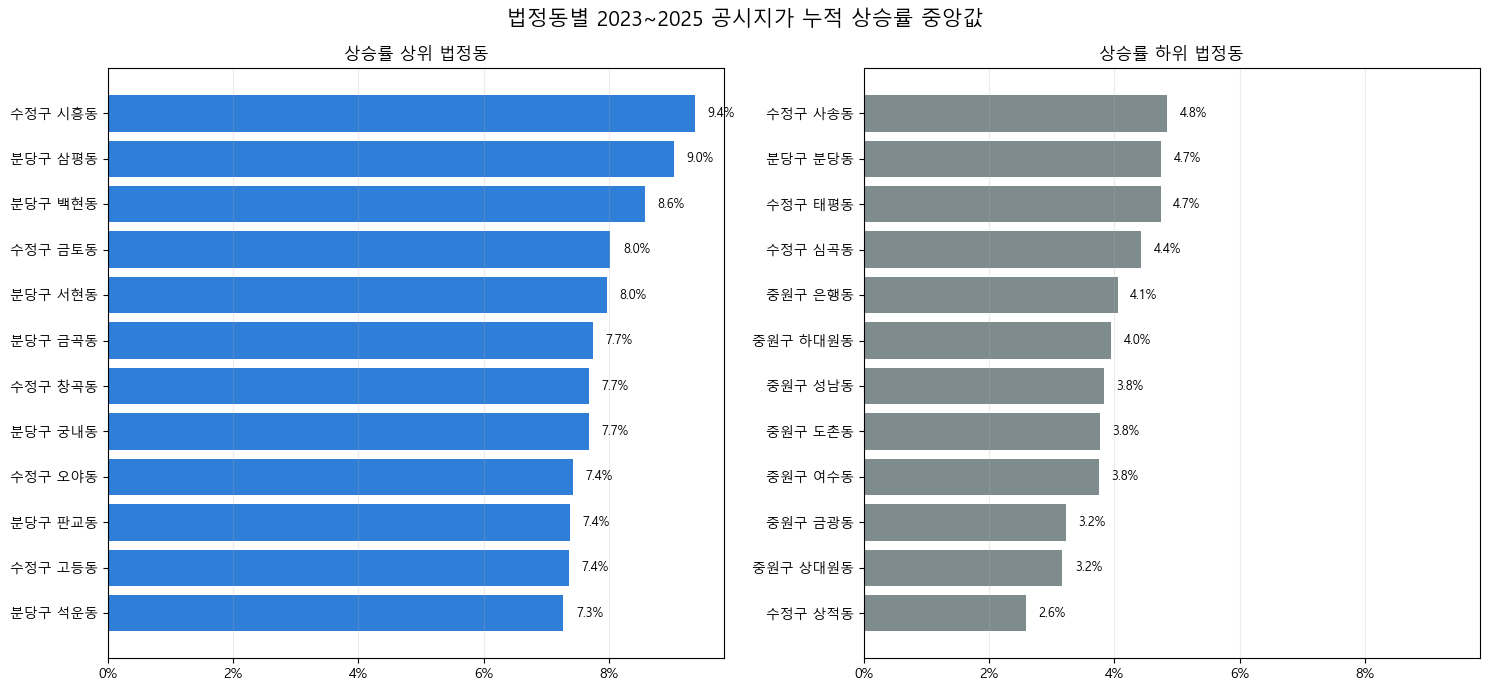

In [17]:
top_n = 12
top_dong = dong_growth_filtered.sort_values("상승률_23_25_중앙", ascending=False).head(top_n).copy()
bottom_dong = dong_growth_filtered.sort_values("상승률_23_25_중앙", ascending=True).head(top_n).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True)
for ax, plot_df, title, color in [
    (axes[0], top_dong, "상승률 상위 법정동", "#2f7ed8"),
    (axes[1], bottom_dong.sort_values("상승률_23_25_중앙", ascending=False), "상승률 하위 법정동", "#7f8c8d"),
]:
    labels = plot_df["구"] + " " + plot_df["법정동"]
    ax.barh(labels, plot_df["상승률_23_25_중앙"], color=color)
    ax.set_title(title)
    ax.xaxis.set_major_formatter(rate_formatter)
    ax.grid(axis="x", alpha=0.25)
    ax.invert_yaxis()
    for i, value in enumerate(plot_df["상승률_23_25_중앙"]):
        ax.text(value + 0.002, i, f"{value:.1%}", va="center", fontsize=9)

fig.suptitle("법정동별 2023~2025 공시지가 누적 상승률 중앙값", fontsize=15)
plt.tight_layout()
plt.show()

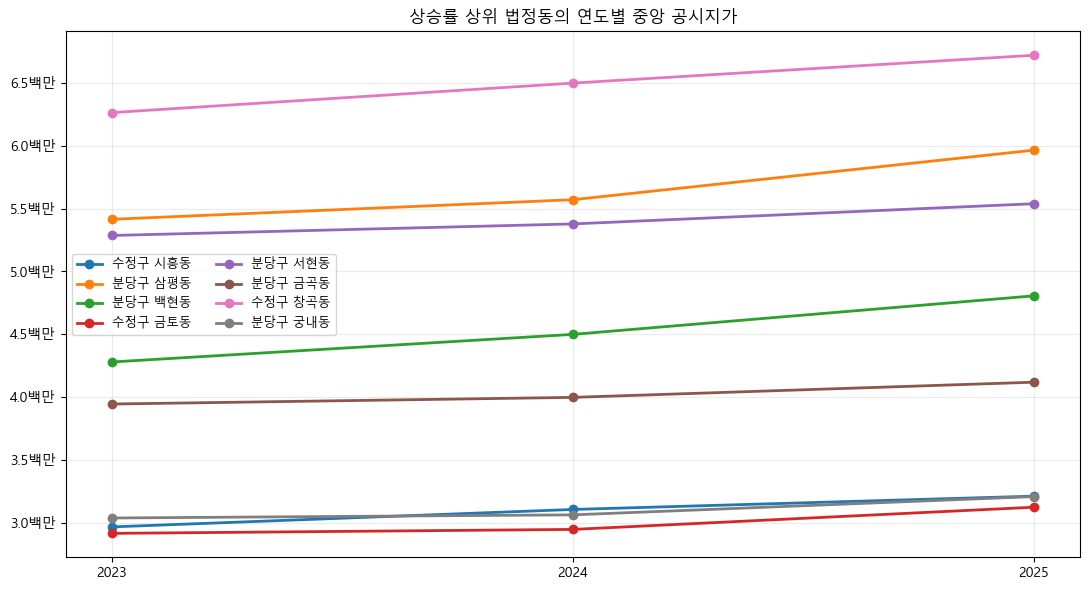

In [18]:
line_dong = top_dong.head(8).copy()
years = [2023, 2024, 2025]
price_cols = ["공시지가_2023_중앙", "공시지가_2024_중앙", "공시지가_2025_중앙"]

fig, ax = plt.subplots(figsize=(11, 6))
for _, row in line_dong.iterrows():
    label = f"{row['구']} {row['법정동']}"
    ax.plot(years, row[price_cols].to_numpy(), marker="o", linewidth=2, label=label)

ax.set_title("상승률 상위 법정동의 연도별 중앙 공시지가")
ax.set_xticks(years)
ax.yaxis.set_major_formatter(price_formatter)
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

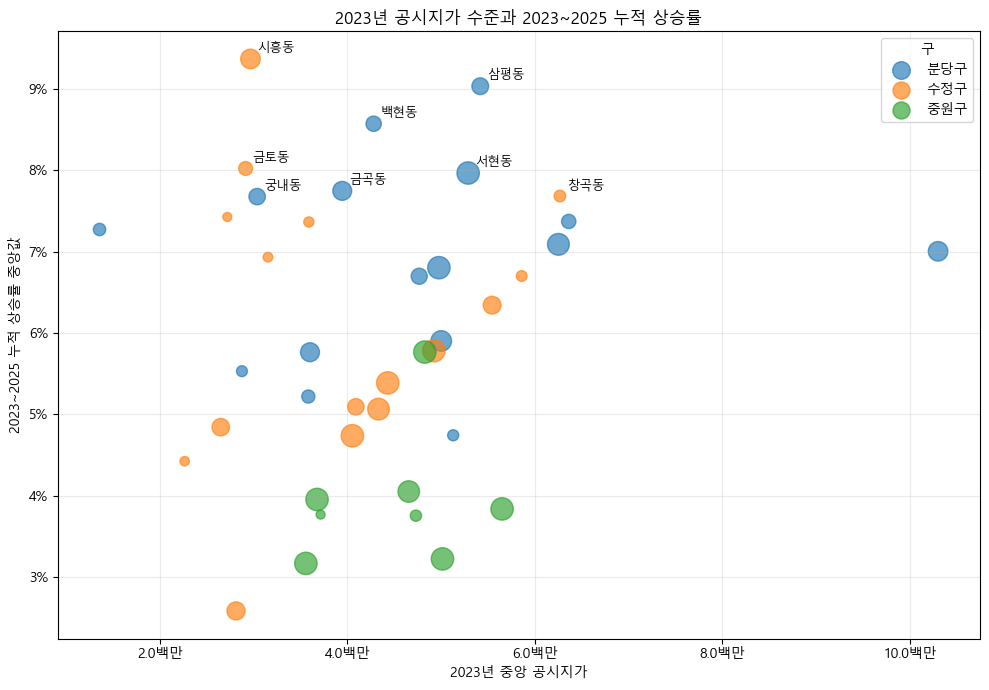

In [19]:
fig, ax = plt.subplots(figsize=(10, 7))
for gu, sub in dong_growth_filtered.groupby("구"):
    sizes = np.clip(sub["필지수"] * 2, 30, 260)
    ax.scatter(
        sub["공시지가_2023_중앙"],
        sub["상승률_23_25_중앙"],
        s=sizes,
        alpha=0.65,
        label=gu,
    )

label_df = dong_growth_filtered.nlargest(8, "상승률_23_25_중앙")
for _, row in label_df.iterrows():
    ax.annotate(
        row["법정동"],
        (row["공시지가_2023_중앙"], row["상승률_23_25_중앙"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_title("2023년 공시지가 수준과 2023~2025 누적 상승률")
ax.set_xlabel("2023년 중앙 공시지가")
ax.set_ylabel("2023~2025 누적 상승률 중앙값")
ax.xaxis.set_major_formatter(price_formatter)
ax.yaxis.set_major_formatter(rate_formatter)
ax.grid(alpha=0.25)
ax.legend(title="구")
plt.tight_layout()
plt.show()

## 7. 그래프별 해석 메모

### 그래프 1. 법정동별 2023~2025 누적 상승률 상위/하위

- 이 그래프는 2023년 1월 대비 2025년 1월 공시지가가 법정동별로 얼마나 올랐는지 비교한 것이다.
- 상승률 상위는 수정구 시흥동(9.37%), 분당구 삼평동(9.04%), 분당구 백현동(8.57%), 수정구 금토동(8.02%), 분당구 서현동(7.97%) 순으로 나타난다.
- 하위는 수정구 상적동(2.59%), 중원구 상대원동(3.17%), 중원구 금광동(3.22%), 중원구 여수동(3.76%), 중원구 도촌동(3.77%) 순으로 낮다.
- 해석할 때는 상승률이 높다고 반드시 공시지가 수준이 높다는 뜻은 아니라는 점을 구분해야 한다. 예를 들어 시흥동과 금토동은 상승률은 높지만 2023년 중앙 공시지가 수준은 분당 주요 동보다 낮은 편이다.

### 그래프 2. 상승률 상위 법정동의 연도별 중앙 공시지가

- 이 선그래프는 상승률 상위 법정동들이 2023년, 2024년, 2025년에 어떤 방향으로 움직였는지 보여준다.
- 대부분의 상위 법정동은 2023년에서 2025년까지 완만하게 우상향한다. 즉, 한 해만 튄 값이라기보다 2년 동안 누적 상승이 이어진 지역이 많다.
- 다만 출발점은 서로 다르다. 판교동, 창곡동, 삼평동, 서현동처럼 2023년 공시지가 수준이 이미 높은 지역도 있고, 시흥동, 금토동, 오야동처럼 상대적으로 낮은 수준에서 상승률이 크게 나온 지역도 있다.
- 따라서 이 그래프는 `가격 수준`과 `상승 속도`를 함께 보는 용도로 쓰는 것이 좋다.

### 그래프 3. 2023년 공시지가 수준과 2023~2025 누적 상승률 산점도

- 이 산점도는 x축에 2023년 중앙 공시지가, y축에 2023~2025 누적 상승률을 놓고 법정동을 비교한 것이다.
- 오른쪽 위에 가까운 법정동은 공시지가 수준도 높고 상승률도 높은 지역이다. 삼평동, 서현동, 창곡동, 판교동, 정자동, 수내동 등이 이 구간에 들어간다.
- 왼쪽 위에 있는 법정동은 현재 가격 수준은 상대적으로 낮지만 상승률이 높은 지역이다. 시흥동, 금토동, 오야동, 석운동 등은 이런 관점에서 볼 수 있다.
- 이 그래프는 기존 통신데이터와 결합할 때 유용하다. 예를 들어 유동인구나 외부유입이 큰 지역이 `고가격·고상승`인지, 아니면 `저가격·고상승`인지 나누어 해석할 수 있다.

### 전체 해석 주의점

- 이 데이터에서는 분기별 상승률보다 **연도별 1월 기준 상승률**이 적절하다.
- 상승률 계산은 같은 `고유번호` 필지를 2023년, 2024년, 2025년으로 맞춘 뒤 진행했다.
- 법정동 대표값은 평균보다 중앙값이 안정적이다. 평균은 특정 필지 하나가 크게 오르거나 내려도 같이 흔들리지만, 중앙값은 해당 동의 일반적인 필지 상승 흐름을 더 잘 보여준다.
- 표본 수가 작은 법정동은 순위 해석이 불안정하므로, 주요 표와 그래프는 `필지수 >= 20` 조건을 적용했다.
- 기존 통신데이터와 결합할 때는 공시지가를 분기 지표처럼 쓰기보다, 해당 연도의 지역 토지가치 변화 보조지표로 붙이는 것이 안전하다. 법정동과 행정동 기준이 다를 수 있으므로 매핑 기준도 따로 확인해야 한다.